# Fiducial BIND lightcone — WL + tSZ statistics

End-to-end statistics for the **fiducial** TNG300 BIND lightcone:
ray-traced convergence (lux) + tSZ Compton-y (lux, same realization geometry) +
per-halo scaling from the composites.

- **κ maps**: `rt_output/run<NNN>/kappa{26,45,59,70,78}.dat` — z_s ≈ 0.5,1,1.5,2,2.44 (100 realizations)
- **y maps**: `rt_output/run<NNN>/y{...}.dat` — cumulative Compton-y to each source plane
- Power spectra via **Pylians**; peaks/minima (8-neighbour); **Minkowski** V0,V1,V2.

Covers 1a (WL×tSZ cross) and 1b (non-Gaussian WL) at the fiducial point;
the Sobol/1P emulator runs reuse this exact stack.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bind.inference import stats as S
from bind.inference.lux_io import load_kappa_realizations, load_y_realizations

RT_ROOT   = "/mnt/home/mlee1/ceph/bind_lightcone_tng/rt_output"
COMP_ROOT = "/mnt/home/mlee1/ceph/bind_lightcone_tng"
FOV_DEG   = 5.0
N_REAL    = 100          # reduce for a quick pass
SNAPS     = [96,90,85,80,76,71,67,63,59,56,52,49,46,43,41,38,35,33,31,29]

kappa, zs = load_kappa_realizations(RT_ROOT, n_real=N_REAL)
print(f"kappa: {kappa.shape} (n_real, n_src, N, N)  z_s={zs}")
try:
    ymaps, _ = load_y_realizations(RT_ROOT, n_real=N_REAL)
    print(f"y:     {ymaps.shape}  ({ymaps.shape[0]} runs with complete y planes)")
except FileNotFoundError:
    ymaps = None; print("y maps not available yet — tSZ sections will skip.")

kappa: (100, 5, 1024, 1024) (n_real, n_src, N, N)  z_s=[0.5  1.   1.5  2.   2.44]
y:     (7, 5, 1024, 1024)  (7 runs with complete y planes)


## 1. Example maps

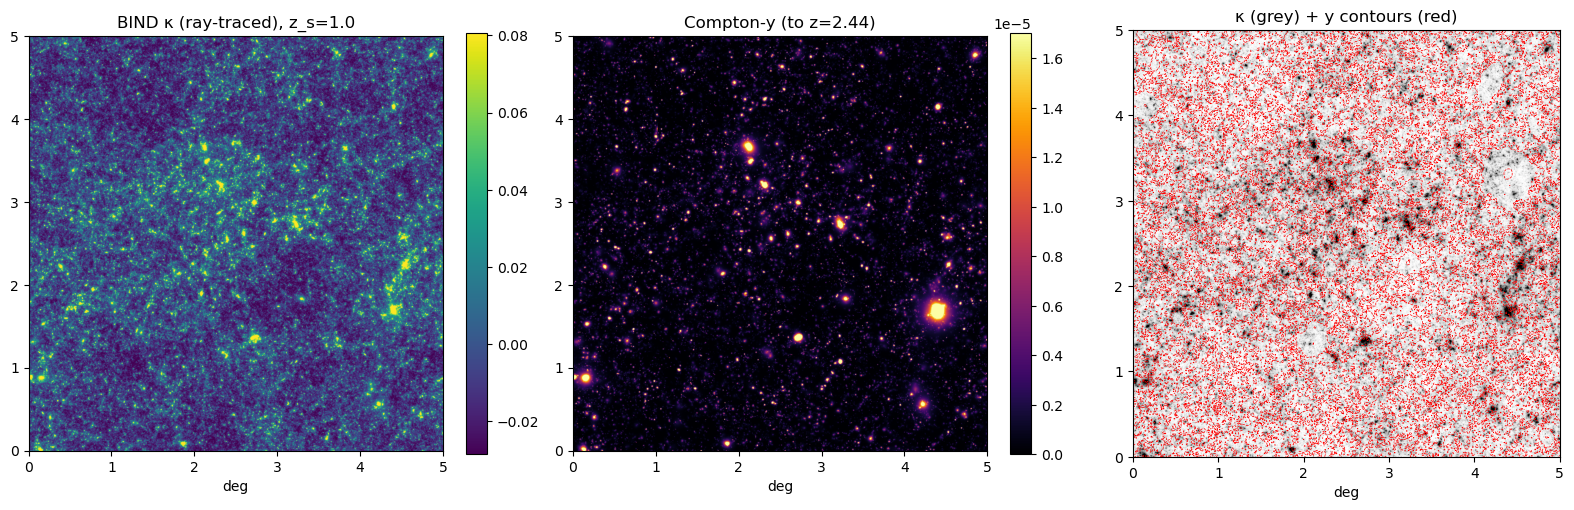

In [2]:
src = 1  # z_s = 1.0
fig, ax = plt.subplots(1, 3 if ymaps is not None else 1, figsize=(16,5))
ax = np.atleast_1d(ax)
im=ax[0].imshow(kappa[0,src], cmap="viridis", extent=[0,FOV_DEG,0,FOV_DEG],
                vmin=np.percentile(kappa[0,src],1), vmax=np.percentile(kappa[0,src],99))
ax[0].set_title(f"BIND κ (ray-traced), z_s={zs[src]}"); plt.colorbar(im,ax=ax[0],fraction=.046)
if ymaps is not None:
    im=ax[1].imshow(ymaps[0,-1], cmap="inferno", extent=[0,FOV_DEG,0,FOV_DEG],
                    vmax=np.percentile(ymaps[0,-1],99.5))
    ax[1].set_title(f"Compton-y (to z={zs[-1]})"); plt.colorbar(im,ax=ax[1],fraction=.046)
    im=ax[2].imshow(kappa[0,src], cmap="Greys", extent=[0,FOV_DEG,0,FOV_DEG],
                    vmin=np.percentile(kappa[0,src],1), vmax=np.percentile(kappa[0,src],99))
    ax[2].contour(np.log10(ymaps[0,-1]+1e-10), levels=4, colors="red", linewidths=0.5,
                  extent=[0,FOV_DEG,0,FOV_DEG])
    ax[2].set_title("κ (grey) + y contours (red)")
for a in ax: a.set_xlabel("deg")
plt.tight_layout(); plt.show()

## 2. WL convergence power spectrum (tomographic)

Auto-spectra per source bin, mean ± scatter over the 100 ray-traced realizations
(via Pylians `Pk_plane`).

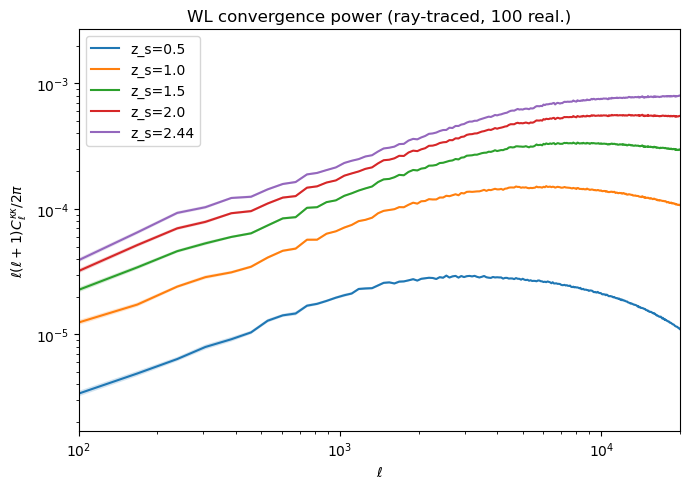

In [3]:
ck = S.cl_kappa(kappa, fov_deg=FOV_DEG)
ell = ck["ell"]
fig, ax = plt.subplots(figsize=(7,5))
for i in range(len(zs)):
    cl = ck["cl"][i,i]; err = ck["cl_err"][i,i]
    f = ell*(ell+1)/(2*np.pi)
    ax.loglog(ell, f*cl, label=f"z_s={zs[i]}")
    ax.fill_between(ell, f*(cl-err), f*(cl+err), alpha=0.2)
ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{\kappa\kappa}/2\pi$")
ax.set_title("WL convergence power (ray-traced, 100 real.)"); ax.legend(); ax.set_xlim(1e2,2e4)
plt.tight_layout(); plt.show()

## 3. Baryonic suppression of the matter power

`S(k) = P_BIND / P_DMO` from the **same-pipeline** projected mass (summed over the
lightcone composites).  Using the same pipeline's DMO cancels the projection MAS
artifact (see the diagnostics notebook); this is the baryonic effect that
propagates into the κ suppression.

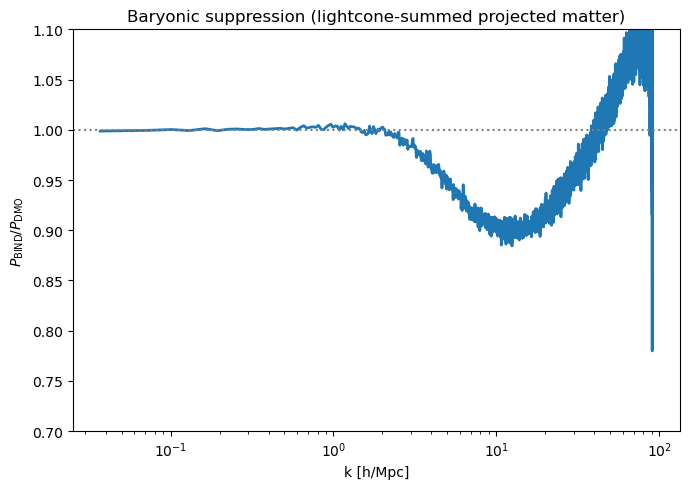

min suppression: 0.780 at k=90.8


In [4]:
import Pk_library as PKL
bind_tot = np.zeros((4198,4198)); dmo_tot = np.zeros((4198,4198))
for s in SNAPS:
    for sl in range(4):
        d = np.load(f"{COMP_ROOT}/snap_{s:03d}/composite_slab{sl:02d}.npz")
        bind_tot += d["composite"].sum(0); dmo_tot += d["dmo"]
def pk(m):
    d=(m/m.mean()-1.0).astype(np.float32)
    p=PKL.Pk_plane(d, 205.0, MAS="None", threads=4, verbose=False)
    return np.asarray(p.k), np.asarray(p.Pk)
kk,pb=pk(bind_tot); _,pd=pk(dmo_tot)
fig,ax=plt.subplots(figsize=(7,5))
ax.semilogx(kk, pb/pd, lw=2)
ax.axhline(1,c="gray",ls=":"); ax.set_ylim(0.7,1.1)
ax.set_xlabel("k [h/Mpc]"); ax.set_ylabel(r"$P_{\rm BIND}/P_{\rm DMO}$")
ax.set_title("Baryonic suppression (lightcone-summed projected matter)")
plt.tight_layout(); plt.show()
print("min suppression: %.3f at k=%.1f"%(np.nanmin(pb/pd), kk[np.nanargmin(pb/pd)]))

## 4. Peak & minimum counts (S/N)

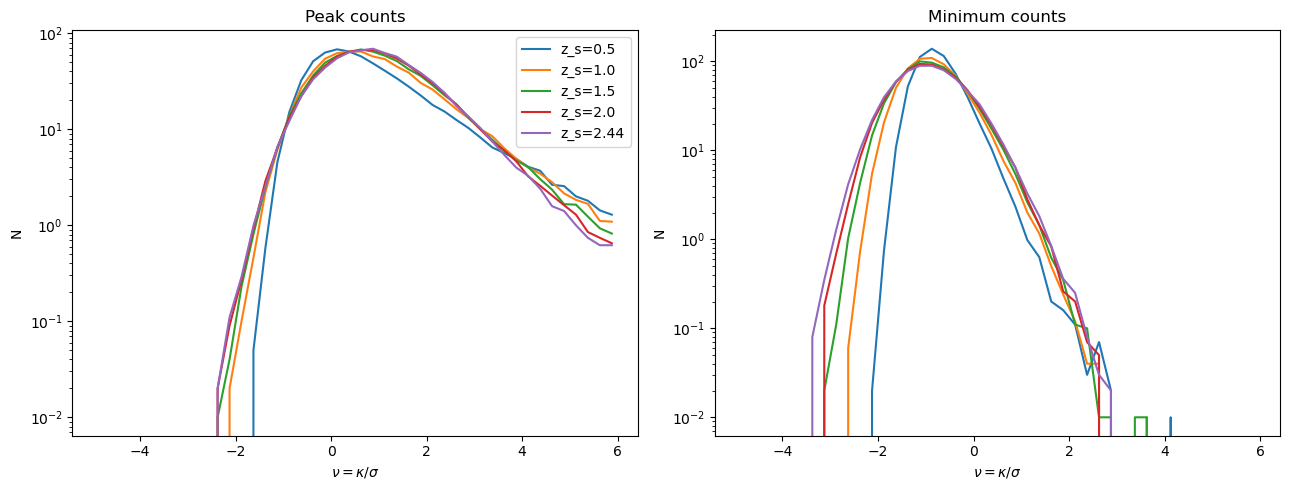

In [5]:
pk_ = S.peak_counts(kappa, fov_deg=FOV_DEG, smoothing_arcmin=2.0)
nu = pk_["nu"]
fig,ax=plt.subplots(1,2,figsize=(13,5))
for i in range(len(zs)):
    ax[0].plot(nu, pk_["peak_counts"][i], label=f"z_s={zs[i]}")
    ax[1].plot(nu, pk_["minima_counts"][i])
ax[0].set_title("Peak counts"); ax[1].set_title("Minimum counts")
for a in ax: a.set_xlabel(r"$\nu=\kappa/\sigma$"); a.set_ylabel("N"); a.set_yscale("log")
ax[0].legend(); plt.tight_layout(); plt.show()

## 5. Non-Gaussian statistics: PDF, moments, Minkowski functionals

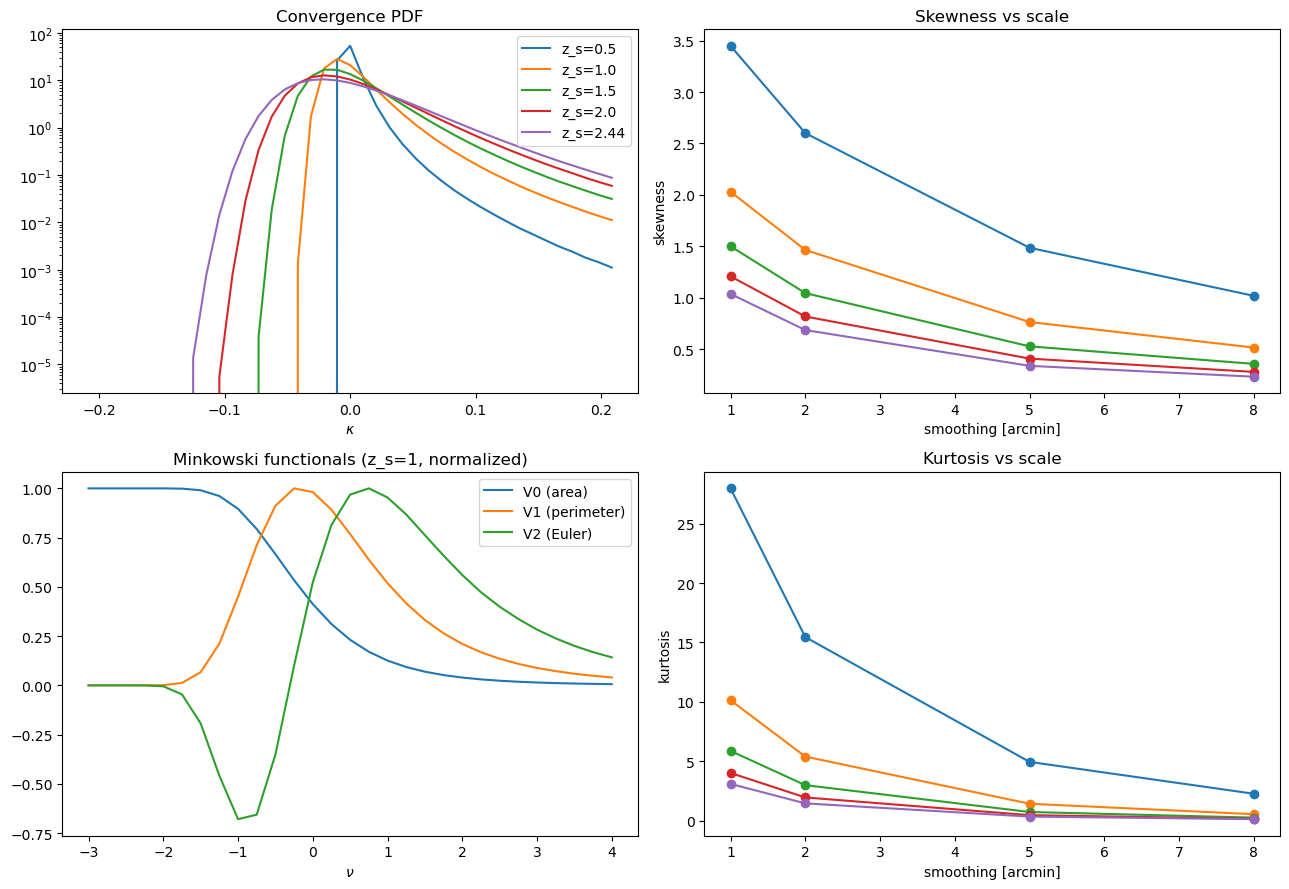

In [6]:
ng = S.nongaussian_stats(kappa, fov_deg=FOV_DEG)
fig,ax=plt.subplots(2,2,figsize=(13,9))
# PDF
for i in range(len(zs)): ax[0,0].plot(ng["pdf_bins"], ng["pdf"][i], label=f"z_s={zs[i]}")
ax[0,0].set_yscale("log"); ax[0,0].set_xlabel(r"$\kappa$"); ax[0,0].set_title("Convergence PDF"); ax[0,0].legend()
# skewness vs scale
sc=ng["smoothing_scales_arcmin"]
for i in range(len(zs)): ax[0,1].plot(sc, ng["skewness"][i], "o-", label=f"z_s={zs[i]}")
ax[0,1].set_xlabel("smoothing [arcmin]"); ax[0,1].set_ylabel("skewness"); ax[0,1].set_title("Skewness vs scale")
# Minkowski V0,V1,V2 at z_s=1
mnu=ng["mf_nu"]
for k,(lab) in enumerate(["V0 (area)","V1 (perimeter)","V2 (Euler)"]):
    ax[1,0].plot(mnu, ng[["V0","V1","V2"][k]][1]/np.abs(ng[["V0","V1","V2"][k]][1]).max(), label=lab)
ax[1,0].set_xlabel(r"$\nu$"); ax[1,0].set_title("Minkowski functionals (z_s=1, normalized)"); ax[1,0].legend()
# kurtosis vs scale
for i in range(len(zs)): ax[1,1].plot(sc, ng["kurtosis"][i], "o-")
ax[1,1].set_xlabel("smoothing [arcmin]"); ax[1,1].set_ylabel("kurtosis"); ax[1,1].set_title("Kurtosis vs scale")
plt.tight_layout(); plt.show()

## 6. tSZ × WL cross-correlation (1a)

`C_ℓ^{κy}` per source bin and the tSZ auto `C_ℓ^{yy}`, from the lux y maps that
share the κ realizations' geometry.

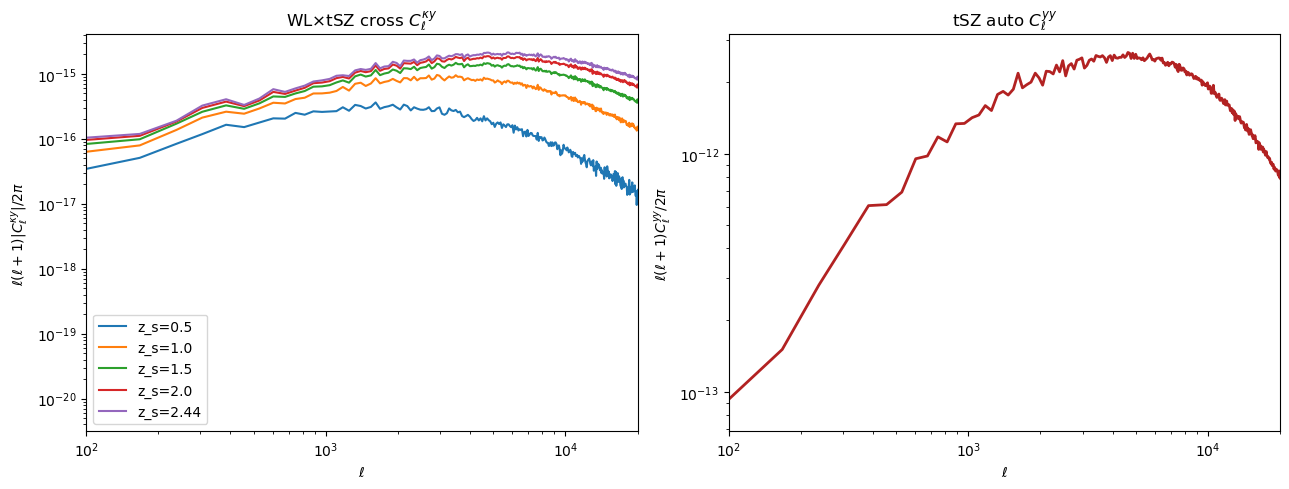

cross computed from 7 realizations; mean y = 1.036e-06


In [7]:
if ymaps is None:
    print("y maps not ready — rerun lux with compute_tsz, then re-run this cell.")
else:
    nr = min(kappa.shape[0], ymaps.shape[0])
    cky = S.cl_kappa_y(kappa[:nr], ymaps[:nr,-1], fov_deg=FOV_DEG)  # cross with full y (to z=2.44)
    ell = cky["ell"]; f = ell*(ell+1)/(2*np.pi)
    fig,ax=plt.subplots(1,2,figsize=(13,5))
    for i in range(len(zs)):
        ax[0].loglog(ell, np.abs(f*cky["cl_ky"][i]), label=f"z_s={zs[i]}")
    ax[0].set_title(r"WL$\times$tSZ cross $C_\ell^{\kappa y}$"); ax[0].legend()
    ax[0].set_xlabel(r"$\ell$"); ax[0].set_ylabel(r"$\ell(\ell+1)|C_\ell^{\kappa y}|/2\pi$")
    ax[1].loglog(ell, f*cky["cl_yy"], lw=2, color="firebrick")
    ax[1].set_title(r"tSZ auto $C_\ell^{yy}$"); ax[1].set_xlabel(r"$\ell$")
    ax[1].set_ylabel(r"$\ell(\ell+1)C_\ell^{yy}/2\pi$")
    for a in ax: a.set_xlim(1e2,2e4)
    plt.tight_layout(); plt.show()
    print(f"cross computed from {nr} realizations; mean y = {ymaps[:,-1].mean():.3e}")

## 7. Per-halo scaling relations

`Y_500c`, gas/star fractions, and mass-weighted temperature vs M200c, from the
composite per-halo patches (a few snapshots across redshift).

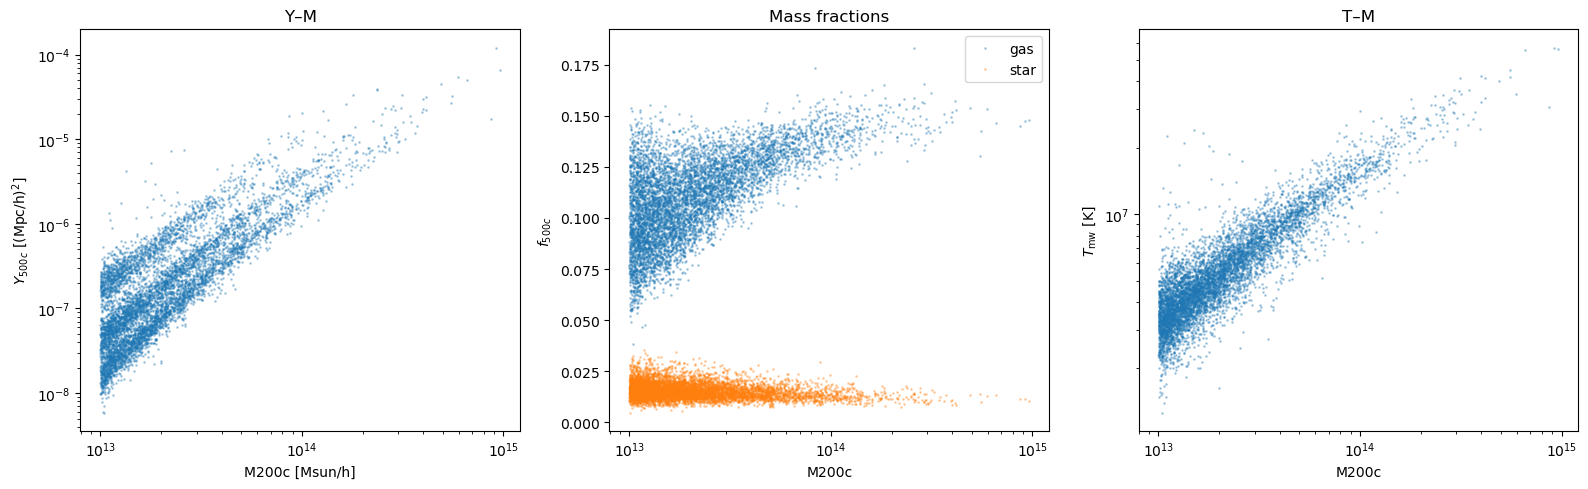

6792 halos | log Y–log M corr = 0.818 (self-similar Y∝M^5/3)


In [8]:
paths=[f"{COMP_ROOT}/snap_{s:03d}/composite_slab{sl:02d}.npz"
       for s in [96,71,46] for sl in range(4)]
hs = S.halo_scaling(paths)
m = hs["halo_mass"]; ok = np.isfinite(hs["Y_500c"]) & (hs["Y_500c"]>0)
fig,ax=plt.subplots(1,3,figsize=(16,5))
ax[0].loglog(m[ok], hs["Y_500c"][ok], ".", ms=2, alpha=.3)
ax[0].set_xlabel("M200c [Msun/h]"); ax[0].set_ylabel(r"$Y_{500c}$ [(Mpc/h)$^2$]"); ax[0].set_title("Y–M")
ax[1].semilogx(m, hs["f_gas_500c"], ".", ms=2, alpha=.3, label="gas")
ax[1].semilogx(m, hs["f_star_500c"], ".", ms=2, alpha=.3, label="star")
ax[1].set_xlabel("M200c"); ax[1].set_ylabel(r"$f_{500c}$"); ax[1].set_title("Mass fractions"); ax[1].legend()
ax[2].loglog(m, hs["T_mw_500c"], ".", ms=2, alpha=.3)
ax[2].set_xlabel("M200c"); ax[2].set_ylabel(r"$T_{\rm mw}$ [K]"); ax[2].set_title("T–M")
plt.tight_layout(); plt.show()
c=np.corrcoef(np.log10(m[ok]), np.log10(hs["Y_500c"][ok]))[0,1]
print(f"{len(m)} halos | log Y–log M corr = {c:.3f} (self-similar Y∝M^5/3)")

## 8. tSZ stacked at WL peaks — R(ν, z_s) (the headline 1a result)

`R(ν) = ⟨y⟩_peaks / ⟨κ⟩_peaks` is a **projected gas-fraction** proxy
(`R ∝ Y/M ∝ f_gas·T_mw`).  Because the lux y maps share the κ realization
geometry, we can stack y at WL-peak locations directly.  Full data vector:
`R(ν,z_s)`, peak counts `N_peaks(ν)`, the **stacked radial y profile** at peaks
(feedback shape), and `Cov(κ_peak, y_peak)` (halo-to-halo gas scatter at fixed ν).
This is the emulator target `R(ν, θ_astro)` for the model-independent baryon /
S8 program.

In [9]:
if ymaps is None:
    print("y maps not ready — rerun lux with compute_tsz first.")
else:
    nr = min(kappa.shape[0], ymaps.shape[0])
    pc = S.peak_cross_stats(kappa[:nr], ymaps[:nr], fov_deg=FOV_DEG, smoothing_arcmin=2.0)
    nu = pc["nu"]
    fig, ax = plt.subplots(2, 2, figsize=(13, 9))
    # R(nu, z_s)
    for i in range(len(zs)):
        ax[0,0].plot(nu, pc["R"][i], "o-", label=f"z_s={zs[i]}")
    ax[0,0].set_xlabel(r"peak S/N $\nu$"); ax[0,0].set_ylabel(r"$R=\langle y\rangle/\langle\kappa\rangle$")
    ax[0,0].set_title("Projected gas fraction R(ν, z_s)"); ax[0,0].legend()
    # N_peaks(nu)
    for i in range(len(zs)):
        ax[0,1].semilogy(nu, pc["n_peaks_total"][i]/nr, "o-")
    ax[0,1].set_xlabel(r"$\nu$"); ax[0,1].set_ylabel("N_peaks / realization"); ax[0,1].set_title("Peak counts")
    # stacked radial y profile at peaks (z_s=1), a few nu bins
    for j in [0, 4, 8]:
        ax[1,0].plot(pc["r_arcmin"], pc["profile"][1, j], label=f"ν≈{nu[j]:.1f}")
    ax[1,0].set_xlabel("r [arcmin]"); ax[1,0].set_ylabel(r"$\langle y(\theta)\rangle_{\rm peaks}$")
    ax[1,0].set_yscale("log"); ax[1,0].set_title("Stacked y profile at peaks (z_s=1)"); ax[1,0].legend()
    # covariance / correlation of (kappa, y) at fixed nu
    for i in range(len(zs)):
        ax[1,1].plot(nu, pc["corr_ky"][i], "o-")
    ax[1,1].axhline(0, c="gray", ls=":"); ax[1,1].set_xlabel(r"$\nu$")
    ax[1,1].set_ylabel(r"corr$(\kappa_{\rm peak}, y_{\rm peak})$")
    ax[1,1].set_title("κ–y scatter at fixed ν (gas variance at fixed mass)")
    plt.tight_layout(); plt.show()
    print(f"R(ν,z_s) from {nr} realizations; rises with ν (gas fraction grows with halo mass).")

AttributeError: module 'bind.inference.stats' has no attribute 'peak_cross_stats'

# Part II — Validation against TNG300 hydro truth

Apples-to-apples: the truth lightcone uses the **same** M≥10¹³ DMO halos, slabs,
transforms and lux ray-tracing as BIND — only the halo fields are the real hydro
sim instead of the model.  The claim to demonstrate: **BIND reproduces the
hydro WL+tSZ statistics** — Cℓκκ, the baryonic suppression, peaks, minima,
non-Gaussian stats, and the tSZ signal.

`BIND ≈ truth` (ratio → 1) across all panels is the validation.

In [ ]:
from pathlib import Path
# BIND fiducial = the existing 100 lux runs; truth = the run_truth_halos pipeline output.
BIND_RT  = "/mnt/home/mlee1/ceph/bind_lightcone_tng/rt_output"
TRUTH_DIR = "/mnt/home/mlee1/ceph/bind_science/runs/truth/run_0000"
COMP_BIND  = "/mnt/home/mlee1/ceph/bind_lightcone_tng"          # BIND composites + stage1 (DMO)
COMP_TRUTH = TRUTH_DIR                                          # truth halo patches

def load_kappa_y(path):
    p = Path(path)
    if (p/"kappa_maps.npz").exists():
        kz=np.load(p/"kappa_maps.npz"); k=kz["kappa"]; z=kz["source_redshifts"]
        y=np.load(p/"y_maps.npz")["y"] if (p/"y_maps.npz").exists() else None
        return k, y, z
    from bind.inference.lux_io import load_kappa_realizations, load_y_realizations
    k,z=load_kappa_realizations(str(p))
    try: y,_=load_y_realizations(str(p))
    except Exception: y=None
    return k, y, z

kB, yB, zs = load_kappa_y(BIND_RT)
print(f"BIND : kappa {kB.shape}  y {None if yB is None else yB.shape}")
TRUTH_READY = (Path(TRUTH_DIR)/"kappa_maps.npz").exists() or any(Path(TRUTH_DIR,"rt").glob("run*")) if Path(TRUTH_DIR).exists() else False
if TRUTH_READY:
    kT, yT, _ = load_kappa_y(TRUTH_DIR)
    print(f"TRUTH: kappa {kT.shape}  y {None if yT is None else yT.shape}")
else:
    kT=yT=None; print("TRUTH not ready yet — run_truth_halos -> paste -> lux -> stats (DESIGN=truth). Truth panels will skip.")

## II.0 Lensplane comparison (before ray-tracing)

While lux runs you can already compare the **lensplanes** that are landing.  Each
`lenspot{p}.dat` holds the lensing-potential derivatives; the per-plane
convergence density is `κ_plane = ½(φ_xx + φ_yy) ∝ δ_plane`.  Comparing BIND vs
truth vs DMO per plane validates the lensing *input* (per redshift slice) before
the full ray-traced integral — and `κ_plane^BIND/κ_plane^DMO` is the baryonic
suppression at each slab redshift.

In [ ]:
from bind.inference.lensplane import read_lensplane
import Pk_library as PKL
LP = {"BIND": Path(COMP_BIND)/"lensplanes",
      "truth": Path(TRUTH_DIR)/"lensplanes",
      "DMO": Path("/mnt/home/mlee1/ceph/bind_science/runs/dmo/run_0000/lensplanes")}
box_eff = 205.0 * 4096 / 4198          # lp_grid crop of the 4198 px / 205 Mpc/h box
SNAPS=[96,90,85,80,76,71,67,63,59,56,52,49,46,43,41,38,35,33,31,29]
def kplane(d, pl):
    f=Path(d)/f"lenspot{pl:02d}.dat"
    if not f.exists(): return None
    phi=read_lensplane(f); return 0.5*(phi[:,:,2]+phi[:,:,4])
def ppk(m):
    d=(m-m.mean()).astype(np.float32); o=PKL.Pk_plane(d,box_eff,MAS="None",threads=4,verbose=False)
    return np.asarray(o.k), np.asarray(o.Pk)
avail={k:v for k,v in LP.items() if v.exists() and any(v.glob("lenspot*.dat"))}
print("lensplane dirs present:", list(avail))
PLANES=[2,26,45,70]   # snap96(z~0), and the z_s~0.5/1/2 output planes
fig,ax=plt.subplots(1,2,figsize=(13,5))
for pl in PLANES:
    z = 1/np.load(f"{COMP_BIND}/snap_{SNAPS[(pl-1)//4]:03d}/stage1/stage1_manifest.json".replace('.json','.json'))['scale_factor']-1 if False else None
    import json as _j
    a=_j.loads(open(f"{COMP_BIND}/snap_{SNAPS[(pl-1)//4]:03d}/stage1/stage1_manifest.json").read())['scale_factor']; z=1/a-1
    spectra={}
    for name,d in avail.items():
        m=kplane(d,pl)
        if m is not None: spectra[name]=ppk(m)
    for name,(k,P) in spectra.items():
        ax[0].loglog(k, k**2*P/(2*np.pi), label=f"{name} plane{pl} (z={z:.2f})" if name=='BIND' else None,
                     color={'DMO':'k','BIND':'C0','truth':'C1'}[name], alpha=0.6)
    if "DMO" in spectra:
        kk,pdmo=spectra["DMO"]
        for name in ("BIND","truth"):
            if name in spectra:
                ax[1].semilogx(spectra[name][0], spectra[name][1]/pdmo,
                               ls="-" if name=="BIND" else "--",
                               label=f"{name}/DMO plane{pl} (z={z:.2f})")
ax[0].set_xlabel("k [h/Mpc]"); ax[0].set_ylabel(r"$k^2 P_{\kappa_{\rm plane}}/2\pi$"); ax[0].set_title("Per-plane lensing density"); ax[0].legend(fontsize=7)
ax[1].axhline(1,c="gray",ls=":"); ax[1].set_ylim(0.7,1.1); ax[1].set_xlabel("k [h/Mpc]")
ax[1].set_ylabel(r"$P/P_{\rm DMO}$"); ax[1].set_title("Per-plane suppression (BIND solid, hydro dashed)"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## II.1 Convergence power spectrum: BIND vs hydro

In [ ]:
ckB=S.cl_kappa(kB,fov_deg=FOV_DEG); ell=ckB["ell"]; f=ell*(ell+1)/(2*np.pi)
fig,ax=plt.subplots(1,2,figsize=(13,5))
for i in range(len(zs)):
    ax[0].loglog(ell,f*ckB["cl"][i,i],color=f"C{i}",label=f"z_s={zs[i]}")
if kT is not None:
    ckT=S.cl_kappa(kT,fov_deg=FOV_DEG)
    for i in range(len(zs)):
        ax[0].loglog(ckT["ell"],ckT["ell"]*(ckT["ell"]+1)/(2*np.pi)*ckT["cl"][i,i],color=f"C{i}",ls="--")
        r=ckB["cl"][i,i]/np.interp(ell,ckT["ell"],ckT["cl"][i,i])
        ax[1].semilogx(ell,r,color=f"C{i}",label=f"z_s={zs[i]}")
    ax[1].axhline(1,c="gray",ls=":"); ax[1].axhspan(0.95,1.05,color="gray",alpha=0.15)
    ax[1].set_ylim(0.8,1.2); ax[1].set_ylabel(r"$C_\ell^{\rm BIND}/C_\ell^{\rm hydro}$")
    ax[1].set_xlabel(r"$\ell$"); ax[1].set_title("BIND / hydro (→1 validates)"); ax[1].legend()
ax[0].set_xlabel(r"$\ell$"); ax[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{\kappa\kappa}/2\pi$")
ax[0].set_title("Cℓκκ — BIND (solid) vs hydro (dashed)"); ax[0].legend(); ax[0].set_xlim(1e2,2e4)
plt.tight_layout(); plt.show()

## II.2 Baryonic suppression: DMO→hydro vs DMO→BIND

The headline power-spectrum test.  `S(k)=P_x/P_DMO` from the lightcone-summed
projected matter (same-pipeline DMO cancels the projection MAS artifact).  BIND's
suppression should track the hydro suppression.

In [ ]:
import Pk_library as PKL
from bind.inference.paint_stages import recomposite_slab
SNAPS=[96,90,85,80,76,71,67,63,59,56,52,49,46,43,41,38,35,33,31,29]
def pk(m):
    d=(m/m.mean()-1).astype(np.float32); pp=PKL.Pk_plane(d,205.0,MAS="None",threads=4,verbose=False)
    return np.asarray(pp.k),np.asarray(pp.Pk)
dmo=np.zeros((4198,4198)); bind=np.zeros((4198,4198)); hyd=np.zeros((4198,4198)); have_h=True
for s in SNAPS:
    d=np.load(f"{COMP_BIND}/snap_{s:03d}/composite_slab00.npz")  # probe
    for sl in range(int(d['n_slabs'])):
        b=np.load(f"{COMP_BIND}/snap_{s:03d}/composite_slab{sl:02d}.npz")
        dmo+=b["dmo"]; bind+=b["composite"].sum(0)
        tp=Path(f"{COMP_TRUTH}/snap_{s:03d}/composite_slab{sl:02d}.npz")
        if have_h and tp.exists():
            bun=recomposite_slab(f"{COMP_BIND}/snap_{s:03d}/stage1/stage1_slab{sl:02d}.npz", tp, r200_factor=4.0)
            if bun is not None: hyd+=bun["composite"].sum(0)
        elif have_h:
            have_h=False
k,pd=pk(dmo); _,pb=pk(bind)
fig,ax=plt.subplots(figsize=(7,5))
ax.semilogx(k,pb/pd,lw=2,label="DMO→BIND")
if have_h: _,ph=pk(hyd); ax.semilogx(k,ph/pd,lw=2,ls="--",label="DMO→hydro (truth)")
else: print("truth composites not present yet — only BIND suppression shown")
ax.axhline(1,c="gray",ls=":"); ax.set_ylim(0.7,1.1); ax.set_xlabel("k [h/Mpc]")
ax.set_ylabel(r"$P_x/P_{\rm DMO}$"); ax.set_title("Baryonic suppression — BIND vs hydro"); ax.legend()
plt.tight_layout(); plt.show()

## II.2b Suppression at the Cℓ level (ray-traced DMO baseline)

The same baryonic suppression but from the **ray-traced** convergence:
`Cℓκκ_BIND/Cℓκκ_DMO` vs `Cℓκκ_hydro/Cℓκκ_DMO` per source bin.  Requires the DMO
lightcone (`run_dmo_lensplane.sh` → lux → stats, DESIGN=dmo).  BIND's κ suppression
should lie on the hydro curve — the cleanest "BIND gives correct WL power" plot.

In [ ]:
DMO_DIR="/mnt/home/mlee1/ceph/bind_science/runs/dmo/run_0000"
if not (Path(DMO_DIR)/"kappa_maps.npz").exists() and not (Path(DMO_DIR,"rt").exists()):
    print("DMO kappa not ready — run run_dmo_lensplane.sh -> lux (COMPUTE_TSZ=False) -> stats (DESIGN=dmo).")
else:
    kD,_,_ = load_kappa_y(DMO_DIR)
    cD=S.cl_kappa(kD,fov_deg=FOV_DEG); cBk=S.cl_kappa(kB,fov_deg=FOV_DEG)
    e=cD["ell"]
    fig,ax=plt.subplots(figsize=(7,5))
    for i in range(len(zs)):
        ax.semilogx(e, cBk["cl"][i,i]/cD["cl"][i,i], color=f"C{i}", lw=2, label=f"BIND  z_s={zs[i]}")
    if kT is not None:
        cTk=S.cl_kappa(kT,fov_deg=FOV_DEG)
        for i in range(len(zs)):
            ax.semilogx(e, np.interp(e,cTk["ell"],cTk["cl"][i,i])/cD["cl"][i,i], color=f"C{i}", lw=2, ls="--")
    ax.axhline(1,c="gray",ls=":"); ax.set_ylim(0.7,1.1); ax.set_xlim(1e2,2e4)
    ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$C_\ell^{\kappa\kappa}/C_\ell^{\rm DMO}$")
    ax.set_title("WL suppression — BIND (solid) vs hydro (dashed), ray-traced")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## II.3 Peak & minimum counts: BIND vs hydro

In [ ]:
pB=S.peak_counts(kB,fov_deg=FOV_DEG); nu=pB["nu"]
pT=S.peak_counts(kT,fov_deg=FOV_DEG) if kT is not None else None
fig,ax=plt.subplots(1,2,figsize=(13,5))
for i in range(len(zs)):
    ax[0].plot(nu,pB["peak_counts"][i],color=f"C{i}",label=f"z_s={zs[i]}")
    ax[1].plot(nu,pB["minima_counts"][i],color=f"C{i}")
    if pT is not None:
        ax[0].plot(nu,pT["peak_counts"][i],color=f"C{i}",ls="--")
        ax[1].plot(nu,pT["minima_counts"][i],color=f"C{i}",ls="--")
ax[0].set_title("Peaks — BIND (solid) vs hydro (dashed)"); ax[1].set_title("Minima")
for a in ax: a.set_xlabel(r"$\nu$"); a.set_yscale("log"); a.set_ylabel("N")
ax[0].legend(); plt.tight_layout(); plt.show()

## II.4 Non-Gaussian stats (PDF, skewness, Minkowski): BIND vs hydro

In [ ]:
ngB=S.nongaussian_stats(kB,fov_deg=FOV_DEG)
ngT=S.nongaussian_stats(kT,fov_deg=FOV_DEG) if kT is not None else None
sc=ngB["smoothing_scales_arcmin"]; src=1
fig,ax=plt.subplots(1,3,figsize=(16,5))
ax[0].plot(ngB["pdf_bins"],ngB["pdf"][src],label="BIND")
if ngT is not None: ax[0].plot(ngT["pdf_bins"],ngT["pdf"][src],ls="--",label="hydro")
ax[0].set_yscale("log"); ax[0].set_title(f"PDF (z_s={zs[src]})"); ax[0].set_xlabel(r"$\kappa$"); ax[0].legend()
ax[1].plot(sc,ngB["skewness"][src],"o-",label="BIND")
if ngT is not None: ax[1].plot(sc,ngT["skewness"][src],"s--",label="hydro")
ax[1].set_title("Skewness vs scale"); ax[1].set_xlabel("arcmin"); ax[1].legend()
for k_,lab in enumerate(["V0","V1","V2"]):
    ax[2].plot(ngB["mf_nu"],ngB[lab][src],color=f"C{k_}",label=f"{lab} BIND")
    if ngT is not None: ax[2].plot(ngT["mf_nu"],ngT[lab][src],color=f"C{k_}",ls="--")
ax[2].set_title("Minkowski (z_s=1; hydro dashed)"); ax[2].set_xlabel(r"$\nu$"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

## II.5 tSZ: Cℓyy and Cℓκy — BIND vs hydro

In [ ]:
if yB is None or kT is None or yT is None:
    print("need BIND y + truth maps for the tSZ comparison.")
else:
    yBt=yB[:,-1] if yB.ndim==kB.ndim else yB; yTt=yT[:,-1] if yT.ndim==kT.ndim else yT
    cB=S.cl_kappa_y(kB,yBt,fov_deg=FOV_DEG); cT=S.cl_kappa_y(kT,yTt,fov_deg=FOV_DEG)
    ell=cB["ell"]; f=ell*(ell+1)/(2*np.pi)
    fig,ax=plt.subplots(1,2,figsize=(13,5))
    ax[0].loglog(ell,f*cB["cl_yy"],lw=2,label="BIND"); ax[0].loglog(ell,f*cT["cl_yy"],lw=2,ls="--",label="hydro")
    ax[0].set_title(r"tSZ auto $C_\ell^{yy}$"); ax[0].set_xlabel(r"$\ell$"); ax[0].legend()
    for i in range(len(zs)):
        ax[1].loglog(ell,np.abs(f*cB["cl_ky"][i]),color=f"C{i}",label=f"z_s={zs[i]}")
        ax[1].loglog(ell,np.abs(f*cT["cl_ky"][i]),color=f"C{i}",ls="--")
    ax[1].set_title(r"WL×tSZ $C_\ell^{\kappa y}$ (hydro dashed)"); ax[1].set_xlabel(r"$\ell$"); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()

## II.6 The SZ / lensing response — R(ν) BIND vs hydro

`R(ν)=⟨y⟩/⟨κ⟩` at WL peaks (projected gas fraction).  The end-to-end science
signal: does BIND reproduce the hydro tSZ-at-peaks response across S/N?

In [ ]:
if yB is None or kT is None or yT is None:
    print("need BIND y + truth per-source-bin y for R(ν).")
else:
    if yB.ndim==kB.ndim and yT.ndim==kT.ndim:
        rB=S.peak_cross_stats(kB,yB,fov_deg=FOV_DEG); rT=S.peak_cross_stats(kT,yT,fov_deg=FOV_DEG)
        fig,ax=plt.subplots(1,2,figsize=(13,5))
        for i in range(len(zs)):
            ax[0].plot(rB["nu"],rB["R"][i],"o-",color=f"C{i}",label=f"z_s={zs[i]}")
            ax[0].plot(rT["nu"],rT["R"][i],"s--",color=f"C{i}")
        ax[0].set_xlabel(r"peak S/N $\nu$"); ax[0].set_ylabel(r"$R=\langle y\rangle/\langle\kappa\rangle$")
        ax[0].set_title("R(ν) — BIND (o) vs hydro (□)"); ax[0].legend()
        ax[1].plot(rB["r_arcmin"],rB["profile"][1,4],"o-",label="BIND")
        ax[1].plot(rT["r_arcmin"],rT["profile"][1,4],"s--",label="hydro")
        ax[1].set_yscale("log"); ax[1].set_xlabel("r [arcmin]"); ax[1].set_ylabel(r"$\langle y\rangle_{\rm peaks}$")
        ax[1].set_title("Stacked y profile at peaks (z_s=1, mid-ν)"); ax[1].legend()
        plt.tight_layout(); plt.show()
    else:
        print("y maps are not per-source-bin (need tomographic y for R(ν)).")

## II.7 Validation summary — BIND/hydro agreement

In [ ]:
if kT is None:
    print("Truth not ready — rerun once the truth lightcone finishes.")
else:
    def band(a,b,ell,lo,hi):
        m=(ell>=lo)&(ell<=hi); return np.nanmean(a[m]/b[m])
    rows=[]
    cB=S.cl_kappa(kB,fov_deg=FOV_DEG); cT=S.cl_kappa(kT,fov_deg=FOV_DEG); e=cB["ell"]
    for i in range(len(zs)):
        rows.append((f"Cℓκκ z_s={zs[i]} (ℓ=300-3000)", band(cB["cl"][i,i],np.interp(e,cT["ell"],cT["cl"][i,i]),e,300,3000)))
    pB=S.peak_counts(kB,fov_deg=FOV_DEG); pT=S.peak_counts(kT,fov_deg=FOV_DEG); hi=pB["nu"]>2
    rows.append(("peak counts (ν>2)", np.nansum(pB["peak_counts"][1][hi])/np.nansum(pT["peak_counts"][1][hi])))
    lo=pB["nu"]<-2
    rows.append(("minima counts (ν<-2)", np.nansum(pB["minima_counts"][1][lo])/np.nansum(pT["minima_counts"][1][lo])))
    if yB is not None and yT is not None and yB.ndim==kB.ndim:
        cyB=S.cl_kappa_y(kB,yB[:,-1],fov_deg=FOV_DEG); cyT=S.cl_kappa_y(kT,yT[:,-1],fov_deg=FOV_DEG)
        rows.append(("Cℓyy (ℓ=300-3000)", band(cyB["cl_yy"],cyT["cl_yy"],cyB["ell"],300,3000)))
    print(f"{'statistic':40s} BIND/hydro")
    print("-"*55)
    for name,r in rows: print(f"{name:40s} {r:.3f}")
    print("\n(values near 1.00 → BIND reproduces the hydro statistic)")